**RoadNet-CA Runtime Testing on Greedy_SOSP**

In [2]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm

from Greedy_SOSP import Greedy_SOSP

DATA_PATH = Path("data") / "roadNet-CA.txt"
RESULTS_GSOSP_CSV = Path("roadNet-CA_results_GSOSP.csv")

In [7]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 5,533,214 edges from data\roadNet-CA.txt


In [12]:
EDGE_COUNTS = [50_000, 100_000, 200_000, 400_000, 800_000, 1_600_000, 3_200_000, len(edge_df)]
REPEAT = 10

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Greedy_SOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 80/80 [06:49<00:00,  5.12s/it]


,edges,nodes,runtime,trial
0,50000,17572,0.038848,1
1,50000,17572,0.036142,2
2,50000,17572,0.030057,3
3,50000,17572,0.036412,4
4,50000,17572,0.030831,5


In [13]:
results_df.to_csv(RESULTS_GSOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_GSOSP_CSV}")

Saved runtime results to roadNet-CA_results_GSOSP.csv


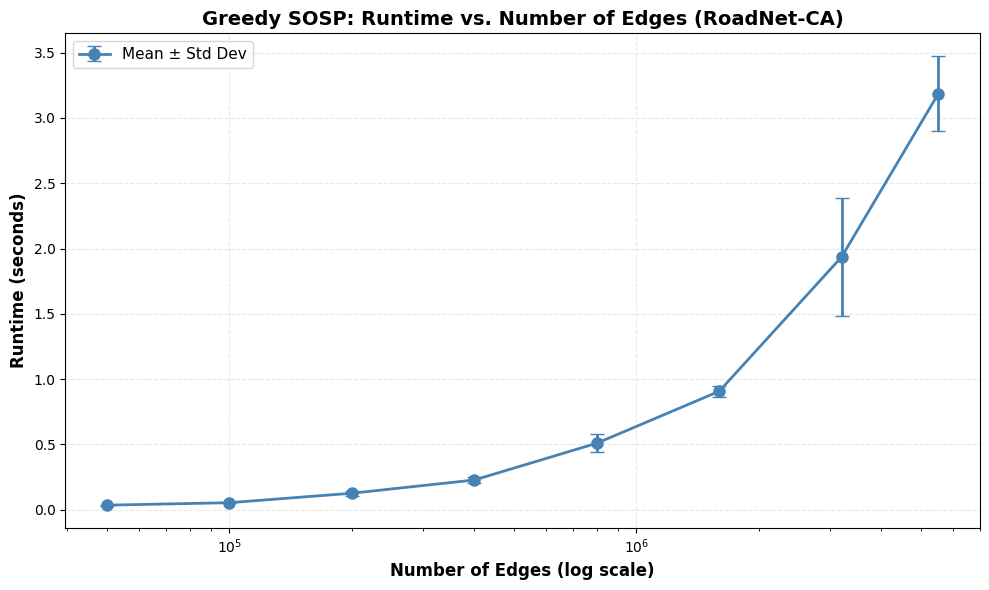


Runtime Statistics by Edges:
  edges     mean      std
  50000 0.034310 0.003623
 100000 0.053082 0.006004
 200000 0.125663 0.019811
 400000 0.226864 0.024575
 800000 0.508584 0.067997
1600000 0.906522 0.043634
3200000 1.935977 0.453859
5533214 3.187320 0.288629


In [4]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Greedy SOSP: Runtime vs. Number of Edges (RoadNet-CA)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))

**RoadNet-CA Runtime Testing on Robust_MOSP**

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from Robust_MOSP import  Robust_MOSP

DATA_PATH = Path("data") / "roadNet-CA.txt"
RESULTS_RMOSP_CSV = Path("roadNet-CA_results_RMOSP.csv")

In [2]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 5,533,214 edges from data\roadNet-CA.txt


In [3]:
EDGE_COUNTS = [50_000, 100_000, 200_000, 400_000, 800_000, 1_600_000, 3_200_000, len(edge_df)]
REPEAT = 10

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Robust_MOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 80/80 [3:49:53<00:00, 172.41s/it]  


,edges,nodes,runtime,trial
0,50000,17572,5.356674,1
1,50000,17572,4.293111,2
2,50000,17572,4.286414,3
3,50000,17572,4.308686,4
4,50000,17572,4.375219,5


In [5]:
results_df.to_csv(RESULTS_RMOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_RMOSP_CSV}")

Saved runtime results to roadNet-CA_results_RMOSP.csv


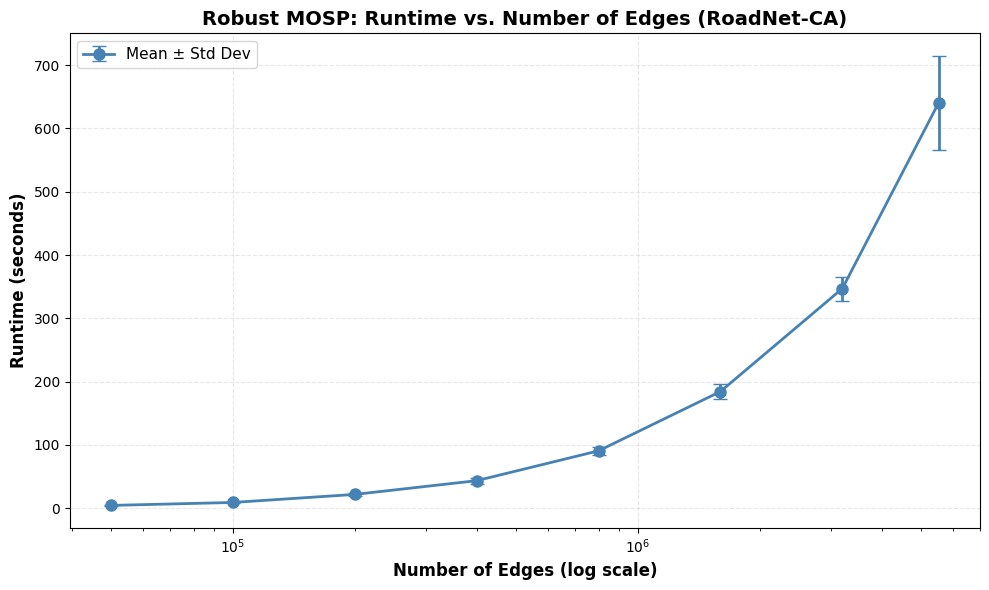


Runtime Statistics by Edges:
  edges       mean       std
  50000   4.422002  0.331178
 100000   9.105207  0.560902
 200000  21.821455  2.478260
 400000  43.516055  4.642352
 800000  90.677852  6.506305
1600000 184.350998 11.446471
3200000 347.027580 18.935077
5533214 640.411091 74.287851


In [6]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Robust MOSP: Runtime vs. Number of Edges (RoadNet-CA)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))